In [1]:
import numpy as np 
import pandas as pd

In [2]:
df=pd.read_csv("df_test.csv")

In [3]:
df.shape

(6700, 14)

In [4]:
df.columns

Index(['date', 'price', 'bedrooms', 'grade', 'has_basement', 'living_in_m2',
       'renovated', 'nice_view', 'perfect_condition', 'real_bathrooms',
       'has_lavatory', 'single_floor', 'month', 'quartile_zone'],
      dtype='object')

In [ ]:
df.info()


In [5]:
df.isna().sum()

date                 0
price                0
bedrooms             0
grade                0
has_basement         0
living_in_m2         0
renovated            0
nice_view            0
perfect_condition    0
real_bathrooms       0
has_lavatory         0
single_floor         0
month                0
quartile_zone        0
dtype: int64

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

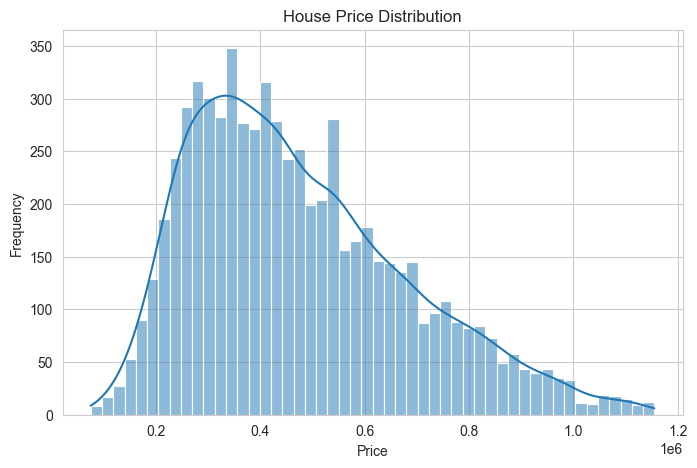

In [8]:
plt.figure()

sns.histplot(df["price"], bins=50, kde=True)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

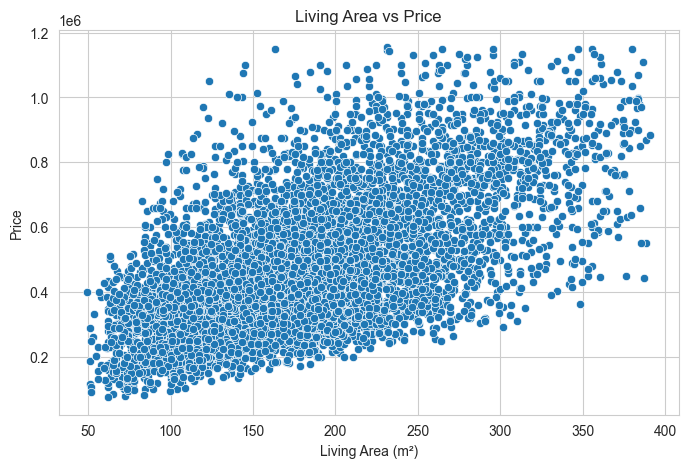

In [9]:
plt.figure()

sns.scatterplot(
    x=df["living_in_m2"],
    y=df["price"]
)

plt.title("Living Area vs Price")
plt.xlabel("Living Area (m²)")
plt.ylabel("Price")

plt.show()

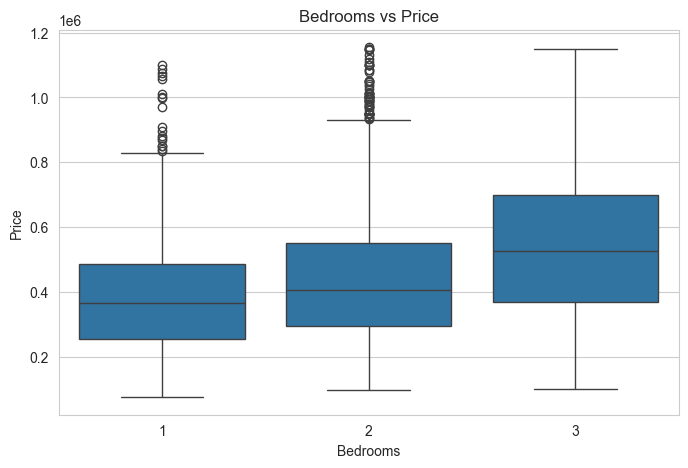

In [10]:
plt.figure()

sns.boxplot(
    x=df["bedrooms"],
    y=df["price"]
)

plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")

plt.show()

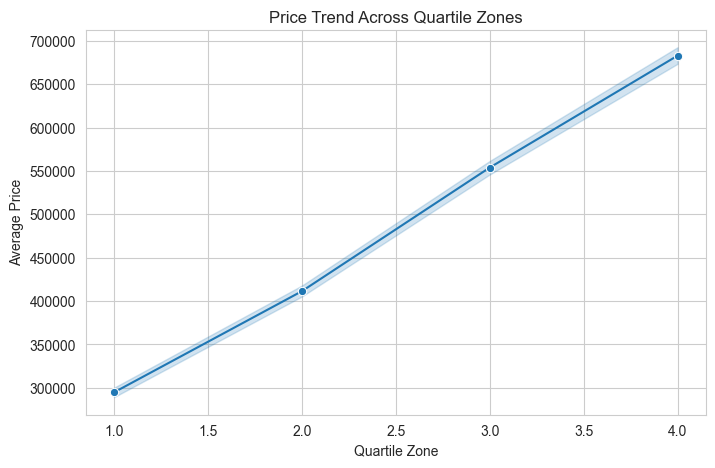

In [11]:
plt.figure()

sns.lineplot(
    x="quartile_zone",
    y="price",
    data=df,
    estimator="mean",
    marker="o"
)

plt.title("Price Trend Across Quartile Zones")
plt.xlabel("Quartile Zone")
plt.ylabel("Average Price")

plt.show()

In [12]:
df["year"] = pd.to_datetime(df["date"]).dt.year

In [13]:
df.drop(columns=['date','has_basement','has_lavatory','month'],inplace=True)

In [14]:
df.head()

,price,bedrooms,grade,living_in_m2,renovated,nice_view,perfect_condition,real_bathrooms,single_floor,quartile_zone,year
0,305000.0,2,1,76.18046,False,False,True,1,True,2,2014
1,498000.0,3,2,210.88981,False,False,False,2,True,2,2014
2,590000.0,2,4,262.91549,False,False,False,2,False,2,2015
3,775000.0,3,3,159.79316,False,False,False,1,False,3,2014
4,350000.0,2,1,92.90300,False,False,False,1,True,3,2015


In [15]:
df.shape

(6700, 11)

In [16]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]

print("Number of outliers:", len(outliers))
print((len(outliers) / len(df)) * 100)

Number of outliers: 82
1.2238805970149254


In [17]:
df = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split as tts

In [20]:
numeric_cols = df.drop(columns=['price']).select_dtypes(include=["int64","float64"]).columns
bool_cols=df.select_dtypes(include=['bool']).columns

preprocessing=ColumnTransformer(
    [('num_cols',StandardScaler(),numeric_cols),
     ('bool_cols', OrdinalEncoder(), bool_cols)]
)

lr_model=Pipeline(
    [('preprocessor',preprocessing),
     ("model",LinearRegression())]
)

In [21]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [22]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=42)

In [24]:
from sklearn.compose import TransformedTargetRegressor

In [25]:
model = TransformedTargetRegressor(
    regressor=lr_model,
    func=np.log,
    inverse_func=np.exp
)


In [26]:
model.fit(x_train,y_train)

TransformedTargetRegressor(func=<ufunc 'log'>, inverse_func=<ufunc 'exp'>,
                           regressor=Pipeline(steps=[('preprocessor',
                                                      ColumnTransformer(transformers=[('num_cols',
                                                                                       StandardScaler(),
                                                                                       Index(['bedrooms', 'grade', 'living_in_m2', 'real_bathrooms', 'quartile_zone'], dtype='object')),
                                                                                      ('bool_cols',
                                                                                       OrdinalEncoder(),
                                                                                       Index(['renovated', 'nice_view', 'perfect_condition', 'single_floor'], dtype='object'))])),
                                                     ('model',
                                                      LinearRegression())]))

In [27]:
y_pd=model.predict(x_test)


In [ ]:
plt.figure()

sns.scatterplot(
    x=y_test,
    y=y_pd,
    color="royalblue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

In [28]:
from sklearn.metrics import r2_score
sc=r2_score(y_test,y_pd)
sc

0.724564474508888

In [2]:
import joblib,os
def save_model(self, path="house_price_model.pkl"):
    if os.path.exists(path):
        choice = input("Model already exists. Do you want to replace it? (y/n): ").strip().lower()
        if choice != "y":
            print("Model was not replaced.")
            return

    joblib.dump(self.model, path)
    print("Model saved successfully.")